# ASL Alphabet Recognition - EDA
Owner/s: **Team BeyondWords**   
Project: **Phase 3 Capstone Project**   
Dataset: **[ASL Alphabet Dataset](https://www.kaggle.com/datasets/grassknoted/asl-alphabet) (from kaggle)**

### Objective:
The goal of this Exploratory Data Analysis (EDA) is to gain a better understanding of the American Sign Language (ASL) Alphabet Dataset before building a machine learning model. This analysis examines the dataset structure, class distribution, image properties, and data quality to identify any patterns or issues that may affect model performance. The findings will help inform preprocessing decisions and support the development of an accurate ASL letter recognition system.

---

### Import libraries:

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

### Set dataset path:

In [5]:
DATASET_PATH = Path("../data/asl_alphabet_train/asl_alphabet_train")

---

### Check folder/class structure:

In [6]:
# Get all subfolders inside the dataset directory (each folder represents a class)
class_folders = [folder for folder in DATASET_PATH.iterdir() if folder.is_dir()]

# Display the total number of classes found
print(f"Number of classes: {len(class_folders)}")

# Display the name of each class folder
print([folder.name for folder in class_folders])

Number of classes: 29
['R', 'U', 'I', 'N', 'G', 'Z', 'T', 'S', 'A', 'F', 'O', 'H', 'del', 'nothing', 'space', 'M', 'J', 'C', 'D', 'V', 'Q', 'X', 'E', 'B', 'K', 'L', 'Y', 'P', 'W']


The dataset follows a well-structured class-based organization with 29 labeled folders, simplifying image classification and model training workflows. The additional `del`, `space`, and `nothing` classes improve real-world usability by allowing the model to handle editing actions, word separation, and non-sign gestures.

---

### Count images per class:

In [7]:
# Count images in each class folder
class_counts = []

for folder in class_folders:
    # Get all image files (.jpg, .png, .jpeg)
    image_files = list(folder.glob("*.jpg")) + list(folder.glob("*.png")) + list(folder.glob("*.jpeg"))
    
    # Store class name and image count
    class_counts.append({
        "class": folder.name,
        "image_count": len(image_files)
    })

# Create and sort summary table
class_counts_df = pd.DataFrame(class_counts).sort_values("class")

# Display image counts per class
class_counts_df

,class,image_count
8,A,3000
23,B,3000
17,C,3000
18,D,3000
22,E,3000
9,F,3000
4,G,3000
11,H,3000
2,I,3000
16,J,3000


The dataset is perfectly balanced, with 3,000 images per class across 29 categories, helping minimize bias and improve classification reliability.

---

### Visualize class distribution: 

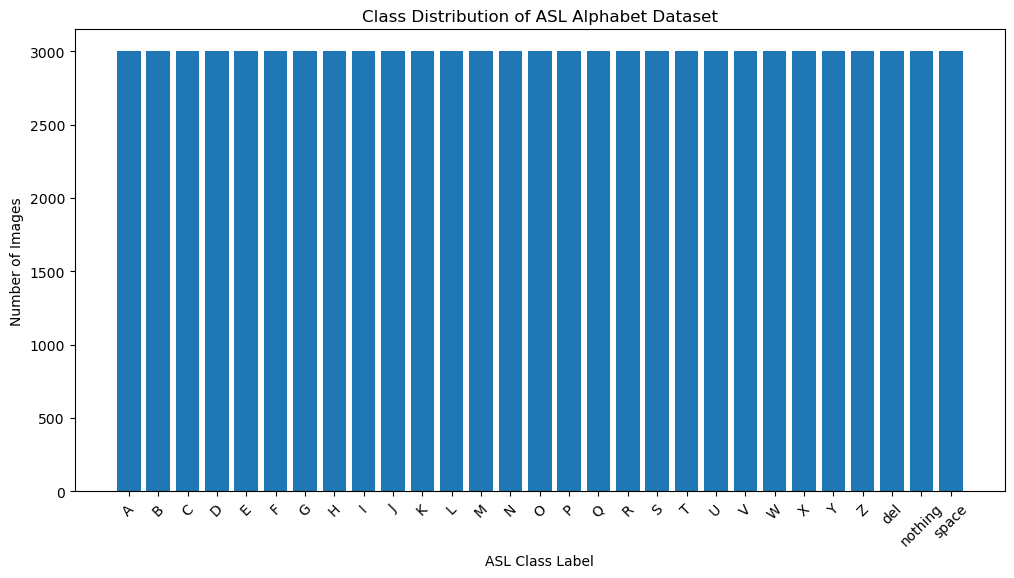

In [9]:
# Create figure and set plot size
plt.figure(figsize=(12, 6))

# Plot image count for each class
plt.bar(class_counts_df["class"], class_counts_df["image_count"])

# Add chart title
plt.title("Class Distribution of ASL Alphabet Dataset")

# Label x-axis
plt.xlabel("ASL Class Label")

# Label y-axis
plt.ylabel("Number of Images")

# Rotate class labels for readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

The dataset is both large and balanced, with 87,000 images evenly distributed across 29 ASL classes, supporting fair and reliable model training.

---

### Basic dataset summary:

In [10]:
# Calculate total number of images in the dataset
total_images = class_counts_df["image_count"].sum()

# Find the smallest class size
min_images = class_counts_df["image_count"].min()

# Find the largest class size
max_images = class_counts_df["image_count"].max()

# Display dataset summary statistics
print(f"Total images: {total_images}")
print(f"Number of classes: {len(class_counts_df)}")
print(f"Minimum images in a class: {min_images}")
print(f"Maximum images in a class: {max_images}")

Total images: 87000
Number of classes: 29
Minimum images in a class: 3000
Maximum images in a class: 3000


---

### Check image dimensions:

In [11]:
# Store image dimensions from sampled images
image_dimensions = []

# Loop through each class folder
for folder in class_folders:
    
    # Sample first 100 images from the class
    image_files = list(folder.glob("*.jpg"))[:100]
    
    # Extract image width and height
    for image_path in image_files:
        with Image.open(image_path) as img:
            width, height = img.size
            
            # Save class label and dimensions
            image_dimensions.append({
                "class": folder.name,
                "width": width,
                "height": height
            })

# Create DataFrame of image dimensions
dimensions_df = pd.DataFrame(image_dimensions)

# Display first few records
dimensions_df.head()

,class,width,height
0,R,200,200
1,R,200,200
2,R,200,200
3,R,200,200
4,R,200,200


The sampled images show a consistent resolution of 200×200 pixels, indicating that the dataset is already standardized and requires minimal resizing during preprocessing.

---

### <u>Dataset Structure & Distribution Findings:</u>
* The dataset contains **29 classes**, including the 26 ASL alphabet letters and the special classes `del`, `space`, and `nothing`.
* A total of **87,000** images were identified, providing a substantial amount of data for training and evaluation.
* Each class contains **3,000** images, resulting in a perfectly balanced dataset with no observable class imbalance.
* Sampled images show a consistent **200×200 pixel** resolution, indicating that the dataset is already standardized for model input.
* The dataset structure and image consistency suggest *minimal preprocessing requirements*, allowing the project to focus on feature extraction and model development.